In [28]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [29]:
#hide
from fastbook import *

In [30]:
#id first_training
#caption Results from the first training
# CLICK ME
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.174680,0.028504,0.010825,00:28


epoch,train_loss,valid_loss,error_rate,time
0,0.057257,0.035647,0.007442,00:37


In [31]:
path

Path('/root/.fastai/data/oxford-iiit-pet/images')

In [32]:
! pwd

/kaggle/working


In [34]:
#hide
# For the book, we can't actually click an upload button, so we fake it
uploader = SimpleNamespace(data = [path / 'Abyssinian_100.jpg'])

In [35]:
#hide
# For the book, we can't actually click an upload button, so we fake it
uploader2 = SimpleNamespace(data = [path / 'keeshond_186.jpg'])

In [36]:
img = PILImage.create(uploader.data[0])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: True.
Probability it's a cat: 1.000000


In [38]:
img = PILImage.create(uploader2.data[0])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: False.
Probability it's a cat: 0.000003


In [39]:
path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

learn = unet_learner(dls, resnet34)
learn.fine_tune(8)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:00&lt;00:00]</div>

epoch,train_loss,valid_loss,time
0,3.751205,2.627995,00:01


epoch,train_loss,valid_loss,time
0,2.110184,1.626604,00:01
1,1.763196,1.250060,00:01
2,1.541474,1.069847,00:01
3,1.355075,0.869561,00:01
4,1.197585,0.765033,00:01
5,1.073401,0.747334,00:01
6,0.972756,0.715667,00:01
7,0.896915,0.705908,00:01


In [48]:
! ls $path/'images'

0001TP_006750.png  0006R0_f03210.png  0016E5_07979.png	  Seq05VD_f00990.png
0001TP_006840.png  0006R0_f03240.png  0016E5_07995.png	  Seq05VD_f01080.png
0001TP_007500.png  0006R0_f03330.png  0016E5_07997.png	  Seq05VD_f01260.png
0001TP_007860.png  0006R0_f03450.png  0016E5_08001.png	  Seq05VD_f01320.png
0001TP_008070.png  0006R0_f03630.png  0016E5_08009.png	  Seq05VD_f01440.png
0001TP_008160.png  0006R0_f03720.png  0016E5_08057.png	  Seq05VD_f01830.png
0001TP_008400.png  0016E5_00720.png   0016E5_08085.png	  Seq05VD_f01890.png
0001TP_008580.png  0016E5_00840.png   0016E5_08089.png	  Seq05VD_f01950.png
0001TP_008670.png  0016E5_01260.png   0016E5_08093.png	  Seq05VD_f02070.png
0001TP_008700.png  0016E5_01500.png   0016E5_08101.png	  Seq05VD_f02370.png
0001TP_008760.png  0016E5_01920.png   0016E5_08125.png	  Seq05VD_f02640.png
0001TP_008940.png  0016E5_02250.png   0016E5_08137.png	  Seq05VD_f02880.png
0001TP_009000.png  0016E5_05190.png   0016E5_08141.png	  Seq05VD_f02940.png
0001TP_00915

In [49]:
! ls $path/'labels'

0001TP_006750_P.png  0016E5_01500_P.png  0016E5_08550_P.png
0001TP_006840_P.png  0016E5_01920_P.png  Seq05VD_f00000_P.png
0001TP_007500_P.png  0016E5_02250_P.png  Seq05VD_f00090_P.png
0001TP_007860_P.png  0016E5_05190_P.png  Seq05VD_f00210_P.png
0001TP_008070_P.png  0016E5_05310_P.png  Seq05VD_f00420_P.png
0001TP_008160_P.png  0016E5_05730_P.png  Seq05VD_f00480_P.png
0001TP_008400_P.png  0016E5_05940_P.png  Seq05VD_f00810_P.png
0001TP_008580_P.png  0016E5_06090_P.png  Seq05VD_f00990_P.png
0001TP_008670_P.png  0016E5_06240_P.png  Seq05VD_f01080_P.png
0001TP_008700_P.png  0016E5_06300_P.png  Seq05VD_f01260_P.png
0001TP_008760_P.png  0016E5_06570_P.png  Seq05VD_f01320_P.png
0001TP_008940_P.png  0016E5_06810_P.png  Seq05VD_f01440_P.png
0001TP_009000_P.png  0016E5_06870_P.png  Seq05VD_f01830_P.png
0001TP_009150_P.png  0016E5_06990_P.png  Seq05VD_f01890_P.png
0001TP_009360_P.png  0016E5_07290_P.png  Seq05VD_f01950_P.png
0001TP_009840_P.png  0016E5_07973_P.png  Seq05VD_f02070_P.png
0001TP_009

In [46]:
! cat $path/'codes.txt'

Animal
Archway
Bicyclist
Bridge
Building
Car
CartLuggagePram
Child
Column_Pole
Fence
LaneMkgsDriv
LaneMkgsNonDriv
Misc_Text
MotorcycleScooter
OtherMoving
ParkingBlock
Pedestrian
Road
RoadShoulder
Sidewalk
SignSymbol
Sky
SUVPickupTruck
TrafficCone
TrafficLight
Train
Tree
Truck_Bus
Tunnel
VegetationMisc
Void
Wall


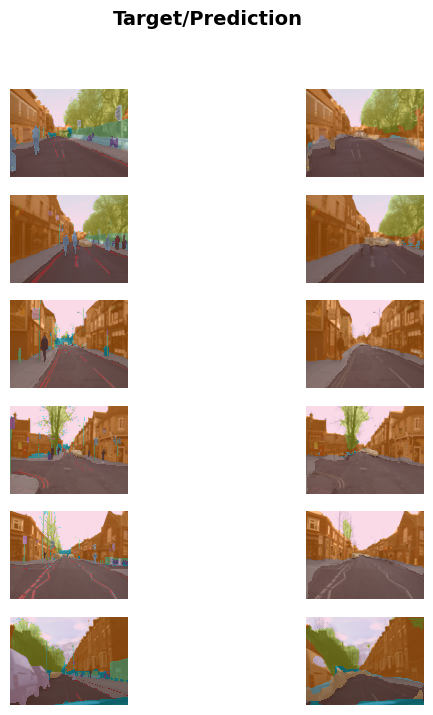

In [50]:
learn.show_results(max_n=6, figsize=(7,8))

In [52]:
from fastai.text.all import *

dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

<div><progress max="144440600" value="144441344"></progress> 100.00% [144441344/144440600 00:03&lt;00:00]</div>

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:02&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,time
0,0.456200,0.389597,0.826440,03:36


epoch,train_loss,valid_loss,accuracy,time
0,0.313203,0.417239,0.823000,07:41
1,0.250395,0.203022,0.919800,07:42
2,0.199415,0.190431,0.927000,07:41
3,0.160229,0.192083,0.928480,07:41


In [55]:
learn.predict("A cinematic masterpiece for anyone who’s ever wondered what it would be like if plot, pacing, and logic all took a vacation at the same time. Bold choice leaving the audience to do all the emotional work—truly interactive filmmaking.")

('pos', tensor(1), tensor([0.0034, 0.9966]))

In [57]:
from fastai.tabular.all import *
path = untar_data(URLs.ADULT_SAMPLE)

dls = TabularDataLoaders.from_csv(path/'adult.csv', path=path, y_names="salary",
    cat_names = ['workclass', 'education', 'marital-status', 'occupation',
                 'relationship', 'race'],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize])

learn = tabular_learner(dls, metrics=accuracy)

<div><progress max="968212" value="974848"></progress> 100.69% [974848/968212 00:00&lt;00:00]</div>

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


In [58]:
learn.fit_one_cycle(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.384932,0.354418,0.840448,00:04
1,0.365889,0.341848,0.846898,00:04
2,0.370292,0.339740,0.849202,00:04


In [59]:
from fastai.collab import *
path = untar_data(URLs.ML_SAMPLE)
dls = CollabDataLoaders.from_csv(path/'ratings.csv')
learn = collab_learner(dls, y_range=(0.5,5.5))
learn.fine_tune(10)

<div><progress max="51790" value="57344"></progress> 110.72% [57344/51790 00:00&lt;00:00]</div>

epoch,train_loss,valid_loss,time
0,1.506399,1.426858,00:00


epoch,train_loss,valid_loss,time
0,1.400139,1.376629,00:00
1,1.297950,1.227301,00:00
2,1.083077,0.949354,00:00
3,0.811495,0.776639,00:00
4,0.705316,0.729834,00:00
5,0.625236,0.713340,00:00
6,0.638774,0.704977,00:00
7,0.611113,0.700441,00:00
8,0.588250,0.698906,00:00
9,0.582810,0.698700,00:00


In [61]:
learn.show_results()

,userId,movieId,rating,rating_pred
0,65.0,37.0,3.0,3.647632
1,15.0,5.0,4.5,3.559524
2,53.0,50.0,5.0,4.143498
3,36.0,59.0,3.0,4.196387
4,71.0,38.0,4.0,4.293056
5,62.0,67.0,4.0,3.769078
6,89.0,84.0,3.5,3.963908
7,14.0,53.0,3.0,3.990816
8,64.0,38.0,4.0,4.274446
